<a href="https://colab.research.google.com/github/Krithika9613/PES-Mtech/blob/Deep_Learning/UNIT_2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import cv2
from matplotlib import pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
data_dir='/content/drive/MyDrive/Deep_Learning/DL_PES_May25/S4_Image_Processing/Images'

In [8]:
img=cv2.imread('/content/drive/MyDrive/Deep_Learning/DL_PES_May25/S4_Image_Processing/Images/mri_tumor1.jpg',0)

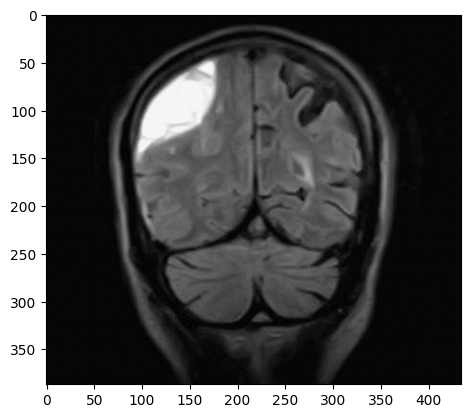

In [9]:
plt.imshow(img,cmap='gray')

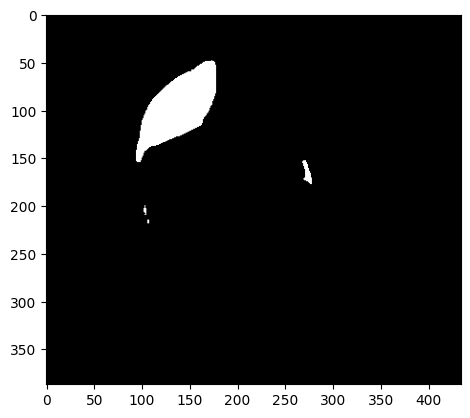

In [10]:
img[img>140]=255
img[img<=140]=0
plt.imshow(img,cmap='gray')

In [ ]:
#Morphological Operations
#Dilation, Erosion, clear border, skeltenization, thickining, thinning, areaopen, closing

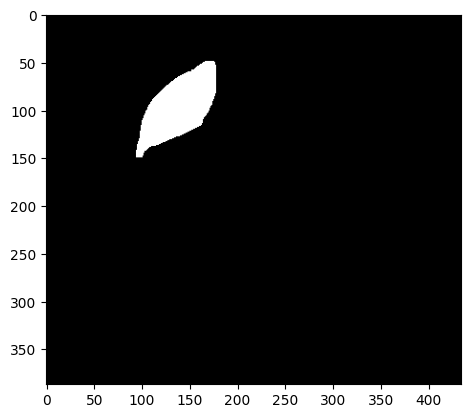

In [11]:
se1=cv2.getStructuringElement(cv2.MORPH_RECT,(7,7))
mask=cv2.morphologyEx(img,cv2.MORPH_OPEN,se1)
plt.imshow(mask,cmap='gray')

In [ ]:
#K means Clustering Approach for Image Segmentation

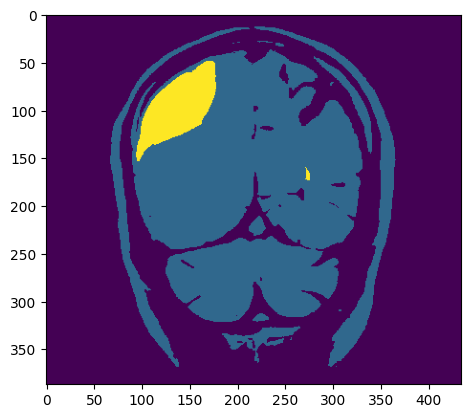

In [19]:
from sklearn.cluster import KMeans

image =cv2.imread(data_dir+'/mri_tumor1.jpg',0)
pixel_vals = image.reshape((-1,1))

mod=KMeans(n_clusters=3,max_iter=1000)
# We defined 3 cluster. Background will go in one cluster, normal tissues of brain will go under second cluster
# Tumor tisseues will comes under third cluster
mod1=mod.fit(pixel_vals)
labels=mod1.labels_
cent=mod1.cluster_centers_
cent=np.uint8(cent)
segmented_data = cent[labels.flatten()]
segmented_image = segmented_data.reshape((image.shape))
plt.imshow(segmented_image)

In [20]:
np.unique(segmented_image)

array([ 11,  83, 223], dtype=uint8)

In [22]:
# segmented_data is already mapped pixels -> cluster center
# If you want each cluster separately:
clust0 = (labels == 0).astype(np.uint8).reshape(image.shape) * 255
clust1 = (labels == 1).astype(np.uint8).reshape(image.shape) * 255
clust2 = (labels == 2).astype(np.uint8).reshape(image.shape) * 255

print("segmented_data shape:", segmented_data.shape)
print("clust0 shape:", clust0.shape)

segmented_data shape: (167958, 1)
clust0 shape: (387, 434)


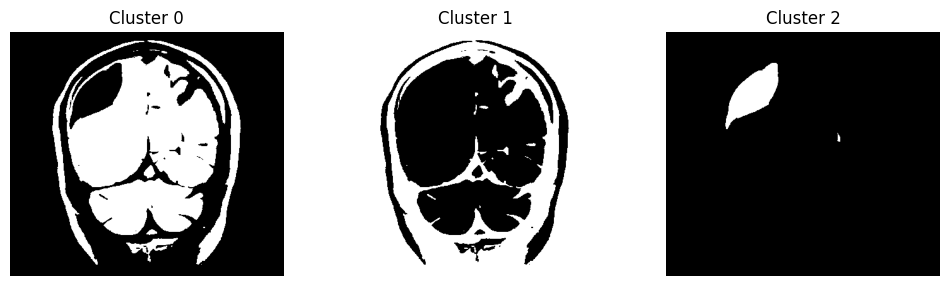

In [23]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Cluster 0")
plt.imshow(clust0, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Cluster 1")
plt.imshow(clust1, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Cluster 2")
plt.imshow(clust2, cmap='gray')
plt.axis('off')

plt.show()

In [24]:
segmented_data.shape,clust0.shape

((167958, 1), (387, 434))

In [ ]:
ind0=np.where(segmented_data==cent[0])
ind1=np.where(segmented_data==cent[1])
ind2=np.where(segmented_data==cent[2])

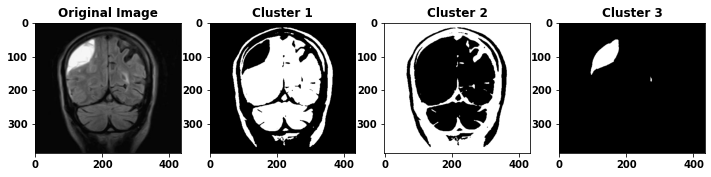

In [ ]:
clust0=segmented_data.copy()
clust0[ind1]=0
clust0[ind2]=0
clust0_image = clust0.reshape((image.shape))

clust1=segmented_data.copy()
clust1[ind0]=0
clust1[ind2]=0
clust1_image = clust1.reshape((image.shape))

clust2=segmented_data.copy()
clust2[ind0]=0
clust2[ind1]=0
clust2_image = clust2.reshape((image.shape))

plt.figure(figsize=(12,10))

plt.subplot(1,4,1)
plt.title('Original Image')
plt.imshow(image,'gray')
plt.subplot(1,4,2)
plt.title('Cluster 1')
plt.imshow(clust0_image,cmap='gray')
plt.subplot(1,4,3)
plt.title('Cluster 2')
plt.imshow(clust1_image,cmap='gray')
plt.subplot(1,4,4)
plt.title('Cluster 3')
plt.imshow(clust2_image,cmap='gray')

In [ ]:
# feature Extraction
# Shape feat, Texture feat, color feat

In [25]:
# Area of RoI = Number of pixels forming that RoI
ar=(mask!=0).sum()
ar

np.int64(4448)

In [26]:
# Max Height and Max Width
# count the number of non zero pixels in each column in the image and pick the max count.
max_h=(mask!=0).sum(axis=0).max()
max_w=(mask!=0).sum(axis=1).max()
max_h,max_w

(np.int64(65), np.int64(66))

In [27]:
#eccentricity
ecc=max_h/max_w
ecc

np.float64(0.9848484848484849)

np.int64(366)

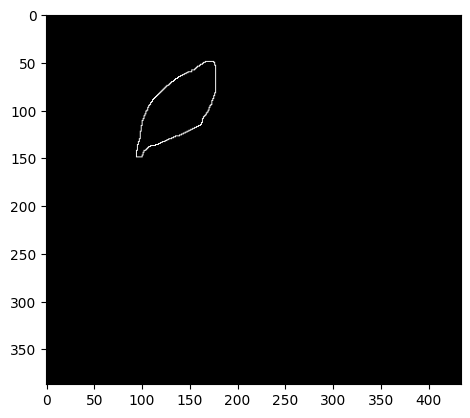

In [28]:
# Permieter
m=np.matrix('-1 -1 -1;-1 8 -1;-1 -1 -1')
edge=cv2.filter2D(mask,-1,m)
plt.imshow(edge,cmap='gray')
peri=(edge!=0).sum()
peri

In [29]:
#centroid
mom=cv2.moments(mask)
x_cent=np.round(mom['m10']/mom['m00'])
y_cent=np.round(mom['m01']/mom['m00'])
print(x_cent,y_cent)

138.0 97.0


In [30]:
contours,_=cv2.findContours(mask,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE)

In [33]:
#Contour Area
cnt=contours[0]
cnt_ar=cv2.contourArea(cnt)
cnt_ar

4315.5

In [34]:
#Hull Area
hull=cv2.convexHull(cnt)
hull_ar=cv2.contourArea(hull)
hull_ar

4562.5

In [35]:
(x,y),rad=cv2.minEnclosingCircle(cnt)
rad

64.3448715209961

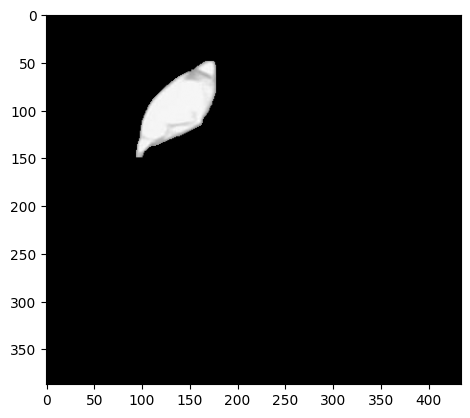

In [37]:
# Texture features
#mean, var, std, skew,
img=cv2.imread(data_dir+'/mri_tumor1.jpg',0)
mask=mask/255
tum=img*mask
plt.imshow(tum,cmap='gray')

In [38]:
#Mean
me=np.mean(tum[tum!=0])
me

np.float64(0.8705406263224715)

In [39]:
#Standard Deviation
sd=np.std(tum[tum!=0])
sd

np.float64(0.10194903982690447)

In [40]:
#skewness
import scipy.stats as stats
sk=stats.skew(tum[tum!=0])
sk

np.float64(-1.5558808873285697)

In [41]:
#Make an array with all the features extracted
feat=np.array([ar,max_h,max_w,ecc,peri,x_cent,y_cent,cnt_ar,hull_ar,rad,me,sd,sk])
feat=feat.reshape((1,-1))
feat=pd.DataFrame(feat)
feat.columns=['Area','Max_Height','Max_Width','Eccntricity','Perimeter','X_centroid','y_centroid','contourArea','HullArea','Radius','Mean','Std','Skew']
feat

,Area,Max_Height,Max_Width,Eccntricity,Perimeter,X_centroid,y_centroid,contourArea,HullArea,Radius,Mean,Std,Skew
0,4448.0,65.0,66.0,0.984848,366.0,138.0,97.0,4315.5,4562.5,64.344872,0.870541,0.101949,-1.555881


In [ ]:
#Say if wee have 1000 images, we can calculate these 13 features for each image and can generate the dataset of size 1000x13
# create the output column for each image with the help of radiologist report
# With this we can build any ML model to predict the cancerous nature of tumor

In [44]:
#case study to find the features from multiple objects (ROI)

img1=cv2.imread(data_dir+'/lung_img.jpg',0)

In [45]:
img1.shape

(512, 512)

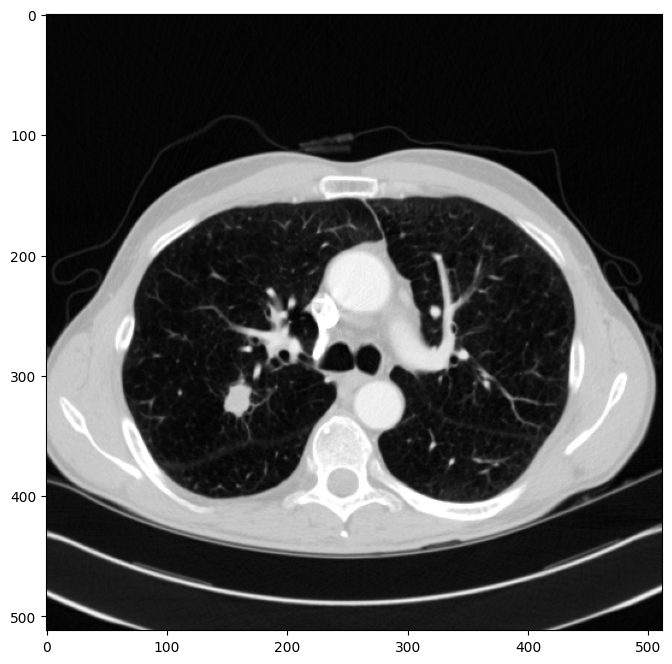

In [46]:
plt.figure(figsize=(8,8))
plt.imshow(img1,cmap='gray')

In [47]:
th,ostu_img=cv2.threshold(img1,0,255,cv2.THRESH_OTSU)

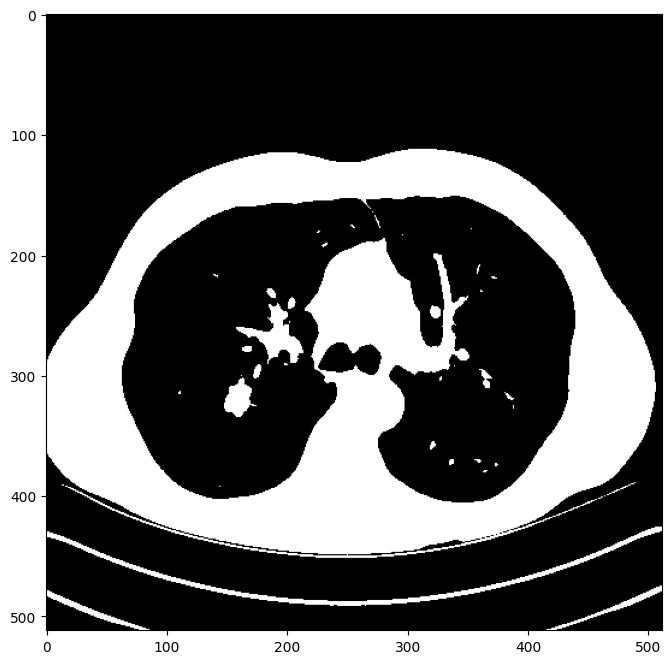

In [48]:
plt.figure(figsize=(8,8))
plt.imshow(ostu_img,cmap='gray')

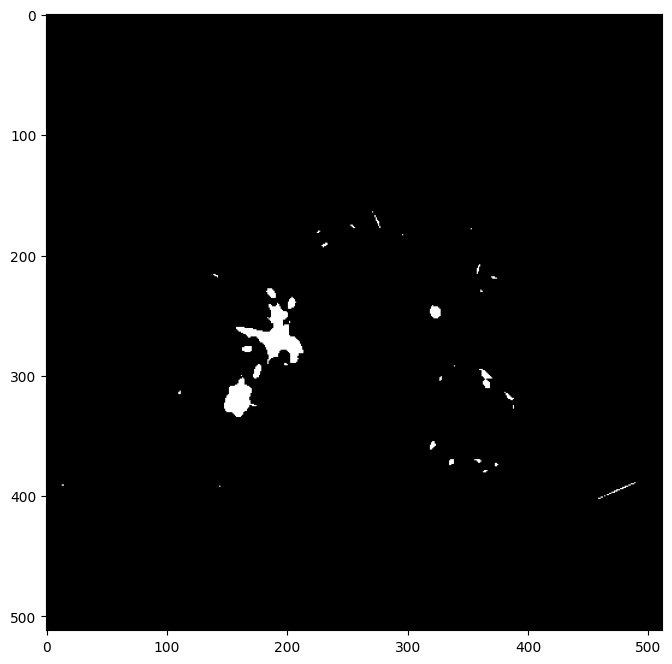

In [49]:
from skimage.segmentation import clear_border
img2=clear_border(ostu_img)
plt.figure(figsize=(8,8))
plt.imshow(img2,cmap='gray')

In [50]:
nlabels,labels,stats,centroids=cv2.connectedComponentsWithStats(img2)

In [51]:
labels

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

In [52]:
stats[:5]

array([[     0,      0,    512,    512, 260126],
       [   271,    164,      1,      1,      1],
       [   273,    167,      5,     11,     14],
       [   253,    175,      4,      3,      6],
       [   353,    178,      1,      1,      1]], dtype=int32)

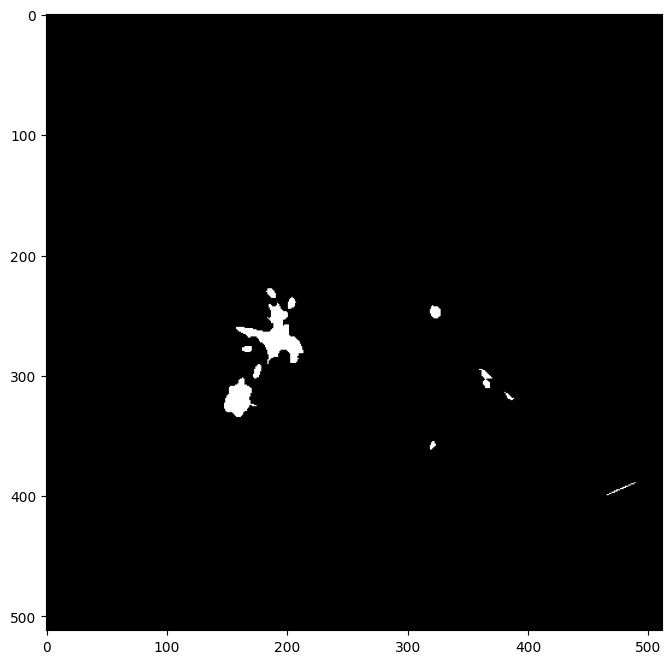

In [53]:
min_size=20
sizes=stats[1:,4]
nodules=np.zeros(labels.shape,dtype='uint8')
for i in range(0,nlabels-1):
  if sizes[i]>=min_size:
    nodules[labels==i+1]=255
plt.figure(figsize=(8,8))
plt.imshow(nodules,cmap='gray')

In [54]:
nodules1=nodules.copy()
nlabels1, labels1, stats1, centroids1 = cv2.connectedComponentsWithStats(nodules1)

all_nod=[]
feat=np.zeros([nlabels1-1,9],dtype='float')
for i in range(1,nlabels1):
    nod1=np.zeros([512,512],dtype='uint8')
    pos=np.where(labels1==i)
    nod1[pos]=nodules1[pos]
    #cv2_imshow(nod1)
    all_nod.append(nod1)

    x,y,w,h = cv2.boundingRect(nod1)
    feat[i-1,0] = float(w)/h #Aspect Ratio
    cc, hierarchy = cv2.findContours(nod1.copy(),cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)
    area = cv2.contourArea(cc[0])
    feat[i-1,1]=area
    rect_area = w*h
    feat[i-1,2]= float(area)/rect_area #Extent
    hull = cv2.convexHull(cc[0])
    hull_area = cv2.contourArea(hull)
    feat[i-1,3]=hull_area #hull area
    feat[i-1,4] = float(area)/hull_area #solidity
    feat[i-1,5] = np.sqrt(4*area/np.pi) #equi_diameter
    [(x,y),(MA,ma),angle] = cv2.fitEllipse(cc[0])
    feat[i-1,6] =angle
feat[:,7]=centroids1[1:,0]
feat[:,8]=centroids1[1:,1]

In [55]:
import pandas as pd
features=pd.DataFrame(feat,columns=['Aspect_Ratio','Area','Extent','Hull_area','Solidity','Equi_dia','Angle','Cent_X','Cent_Y'])
features

,Aspect_Ratio,Area,Extent,Hull_area,Solidity,Equi_dia,Angle,Cent_X,Cent_Y
0,1.000000,33.0,0.515625,34.5,0.956522,6.482045,140.862686,186.840909,231.477273
1,0.700000,35.5,0.507143,38.0,0.934211,6.723095,17.001564,203.574468,239.914894
2,1.098039,879.0,0.307773,1712.0,0.513435,33.454111,134.371429,191.185714,267.161224
3,0.818182,62.0,0.626263,64.5,0.961240,8.884866,159.682098,323.105263,247.210526
4,1.600000,24.5,0.612500,25.5,0.960784,5.585192,86.792854,166.742857,277.942857
5,0.583333,42.5,0.505952,46.5,0.913978,7.356132,18.717096,175.160714,296.589286
6,0.687500,54.5,0.309659,87.0,0.626437,8.330159,160.438629,365.157895,302.631579
7,0.818182,450.0,0.505051,555.5,0.810081,23.936537,15.863496,159.531313,319.365657
8,1.142857,11.0,0.196429,15.0,0.733333,3.742410,128.787842,384.400000,317.500000
9,0.714286,15.0,0.428571,16.0,0.937500,4.370194,27.145115,320.782609,358.000000


In [56]:
data=pd.read_csv(data_dir+'/dataset.csv')

In [ ]:
data.head(10)

,F1,F3,F5,F7,F8,F10,F12,F14,F16,F19,F22,F26,T
0,61.8750,32.077140,449.71875,1.000000,0.758333,14.650000,0.772116,1.001611,0.462735,276.318695,3.681973e+05,0.595376,False
1,14.0625,16.749615,56.30625,0.900000,0.693333,7.850000,0.514698,1.002350,0.182834,318.816223,1.327357e+04,0.235717,False
2,150.7500,69.914100,1507.10625,1.000000,0.933333,40.450000,0.341068,1.001946,-0.674083,234.604446,1.574722e+06,-0.381766,True
3,11.8125,13.560380,127.96875,0.333333,0.333333,11.400000,0.454123,1.002419,0.095425,275.847107,1.102121e+04,0.062675,False
4,20.2500,21.604931,258.86250,0.923077,0.494505,15.316667,0.435236,1.002237,-0.396786,245.214554,2.239375e+04,-0.431358,False
5,13.5000,15.744046,127.23750,0.866667,0.693333,13.400000,0.316280,0.980073,-0.555117,252.875107,1.348662e+04,-0.191449,False
6,80.4375,36.515936,303.46875,0.833333,0.288889,11.483333,0.735423,1.001999,-0.279554,218.248688,5.472069e+05,-0.247362,False
7,17.4375,16.577086,185.00625,0.550000,0.550000,13.400000,0.473269,1.012867,0.351657,398.973846,9.302181e+03,0.111234,False
8,36.5625,25.038158,220.10625,0.562500,0.562500,10.783333,0.680652,1.011371,-0.160937,319.224579,4.934062e+04,0.251575,True
9,14.6250,15.988038,228.88125,0.565217,0.535714,18.550000,0.414310,1.012091,0.454289,360.464874,7.107524e+03,0.329108,False


In [57]:
data.shape

(283, 13)

In [58]:
data['T'].value_counts()

,count
T,
False,252
True,31


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix

In [60]:
inp=data.drop('T',axis=1)
out=data['T']

In [61]:
xtrain,xtest,ytrain,ytest=train_test_split(inp,out,test_size=0.3,random_state=48)

In [62]:
logr=LogisticRegression(max_iter=2000)
logr.fit(xtrain,ytrain)
ypred=logr.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

       False       0.95      0.99      0.97        77
        True       0.80      0.50      0.62         8

    accuracy                           0.94        85
   macro avg       0.88      0.74      0.79        85
weighted avg       0.94      0.94      0.93        85



In [63]:
rf=RandomForestClassifier(random_state=48)
rf.fit(xtrain,ytrain)
ypred=rf.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

       False       0.95      0.99      0.97        77
        True       0.80      0.50      0.62         8

    accuracy                           0.94        85
   macro avg       0.88      0.74      0.79        85
weighted avg       0.94      0.94      0.93        85



In [ ]:
#Collecting more data on cancerous nodules will improve recall of the model